# プロジェクト概要
- RNAデータの主成分分析（PCA）を行いました
- PCAで次元を削減したデータに対し、k-means法によるクラスタリングを行いました
- pandas、matplotlib、numpy、sklearnライブラリを使用しました

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# 1. 主成分分析（PCA）

### データの読み込みとコラムの整理

In [3]:
data = pd.read_csv("data.csv")
for col in data.columns:
    if data[col].dtype == "object":
        data = data.drop(columns=[col])
data.shape
data

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,0.0,...,6.088133,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000
797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,0.0,...,6.371876,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000
798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,0.0,...,5.719386,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693
799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,0.0,...,5.785237,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000


### PCAの実行と可視化

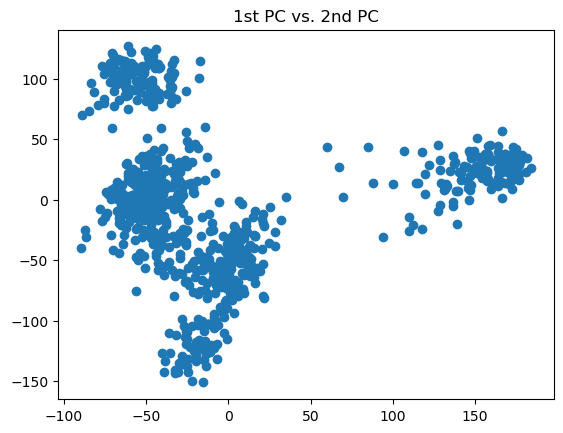

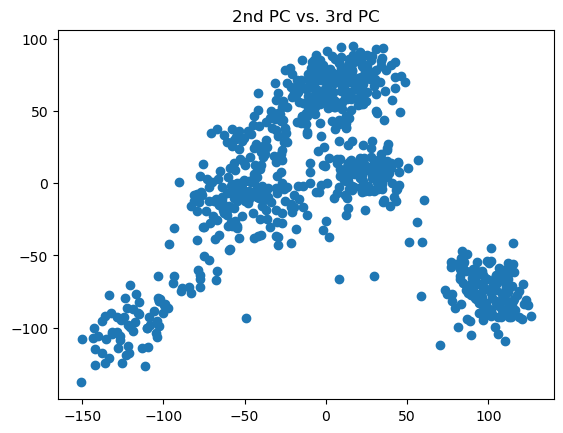

In [6]:
model = PCA(n_components=3)
model.fit(data)
reduced_x = model.fit_transform(data)
plt.scatter(reduced_x[:,0],reduced_x[:,1])
plt.title("1st PC vs. 2nd PC")
plt.show()
plt.scatter(reduced_x[:,1],reduced_x[:,2])
plt.title("2nd PC vs. 3rd PC")
plt.show()

# 2. K-means法

### K-means法によるクラスタリングを実行

In [14]:
model2 = KMeans(n_clusters=5, random_state=2025)
model2.fit(reduced_x)
predicted_label = model2.predict(reduced_x)

### クラスターの可視化

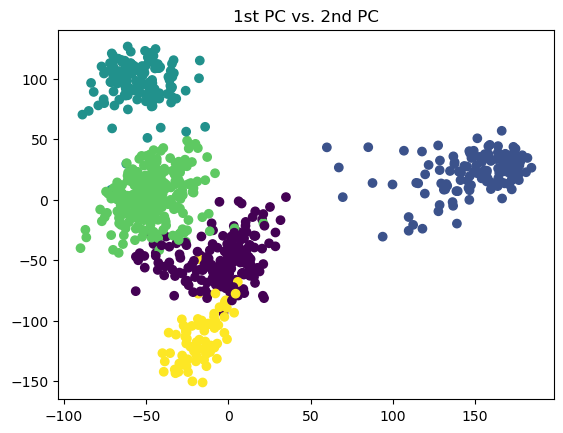

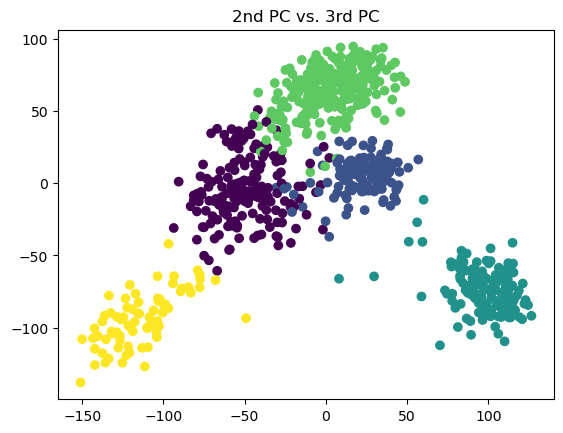

In [15]:
ze = np.zeros([reduced_x.shape[0],1])
newx = np.concat([reduced_x,ze],axis=1)
for i in range(reduced_x.shape[0]):
    newx[i,3]=predicted_label[i]

plt.scatter(newx[:,0],newx[:,1],c=newx[:,3])
plt.title("1st PC vs. 2nd PC")
plt.show()

plt.scatter(newx[:,1],newx[:,2],c=newx[:,3])
plt.title("2nd PC vs. 3rd PC")
plt.show()